In [1]:
import numpy as np
import astropy.units as u
# import glob
# import os
# import colorsys

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
# import pandas as pd
# import seaborn as sns
# import matplotlib.colors as colors
# from matplotlib.patches import Patch
# from matplotlib.lines import Line2D
# import matplotlib.gridspec as gridspec

import chime_frb_constants as constants

In [2]:
# Default plot parameters
plt.rcParams.update({
    "figure.dpi": 300,
    "figure.figsize": (8, 6),
    "font.size": 12,
    "font.family": "serif",
    "figure.titlesize": 16,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.grid": False,
    "savefig.bbox": "tight",
})

# Get data

In [ ]:
# Time resolution of data 
SAMPLE_RATE = constants.FPGA_COUNTS_PER_SECOND * u.Hz  # samples per second (time axis sampling)
stokes_time_res_ch = [391, 781, 1563, 3125, 6250, 12500, 25000]  # in number of channels
stokes_time_res = [(ch/SAMPLE_RATE).to(u.ms) for ch in stokes_time_res_ch]  # in ms
Ntime_res = len(stokes_time_res)

# parameter varied
PARAM_NAME = 'timestep'  # name of parameter in file/dict names
# PARAM_VAR = 'search_time_step'  # name of variable in script & saved data
param_label = 'Downsampling Factor'
param_vals = [4, 8, 16, 32, 48, 64, 96, 128, 192, 256]  # in number of channels --> equiv time depends on time_res of data
Nparam = len(param_vals)

# quantity to plot
QTY = "cpu_elapsed"

In [4]:
# Paths
RESULT_DIR = "/scratch/abernier/pulsar_data/search_results/"
SOURCE = "2022_CHIME_B2111+46_"
NIGHT = "20220826T064420Z"

In [5]:
# Initialize data arrays
CPU_time_search = np.zeros((Ntime_res, Nparam))  # array for CPU time during RM serch step
CPU_time_total = np.zeros((Ntime_res, Nparam))  # array for total CPU time

# **opening with a loop since we want to keep the right ordering and only get specific files**

# Loop over time resolutions
for i, t_res_ch in enumerate(stokes_time_res_ch):
    # Get correct directory
    time_res_dir = f"{NIGHT}_bands6_timeavg{t_res_ch}_300files_start160/"
    abs_dir_path = RESULT_DIR + time_res_dir + f"{PARAM_NAME}/"

    # To store time values for all files of current time res
    search_time_list = []
    total_time_list = []
    
    # Loop over parameter values
    for j, param in enumerate(param_vals):
        metadata_file = abs_dir_path + f"{SOURCE}{NIGHT}_{PARAM_NAME}{param}_metadata.npz"

        # Open file
        metadata_dict = np.load(metadata_file, allow_pickle=True)['metadata'].item()
        timings = metadata_dict['timings']

        # Append time info to lists
        search_time_list.append(timings['rm_search']['cpu_elapsed'])
        total_time_list.append(timings['total']['cpu_elapsed'])

    # # Add time lists to data arrays
    CPU_time_search[i,:] = np.array(search_time_list)
    CPU_time_total[i,:] = np.array(total_time_list)

# Plot

CPU time during search step

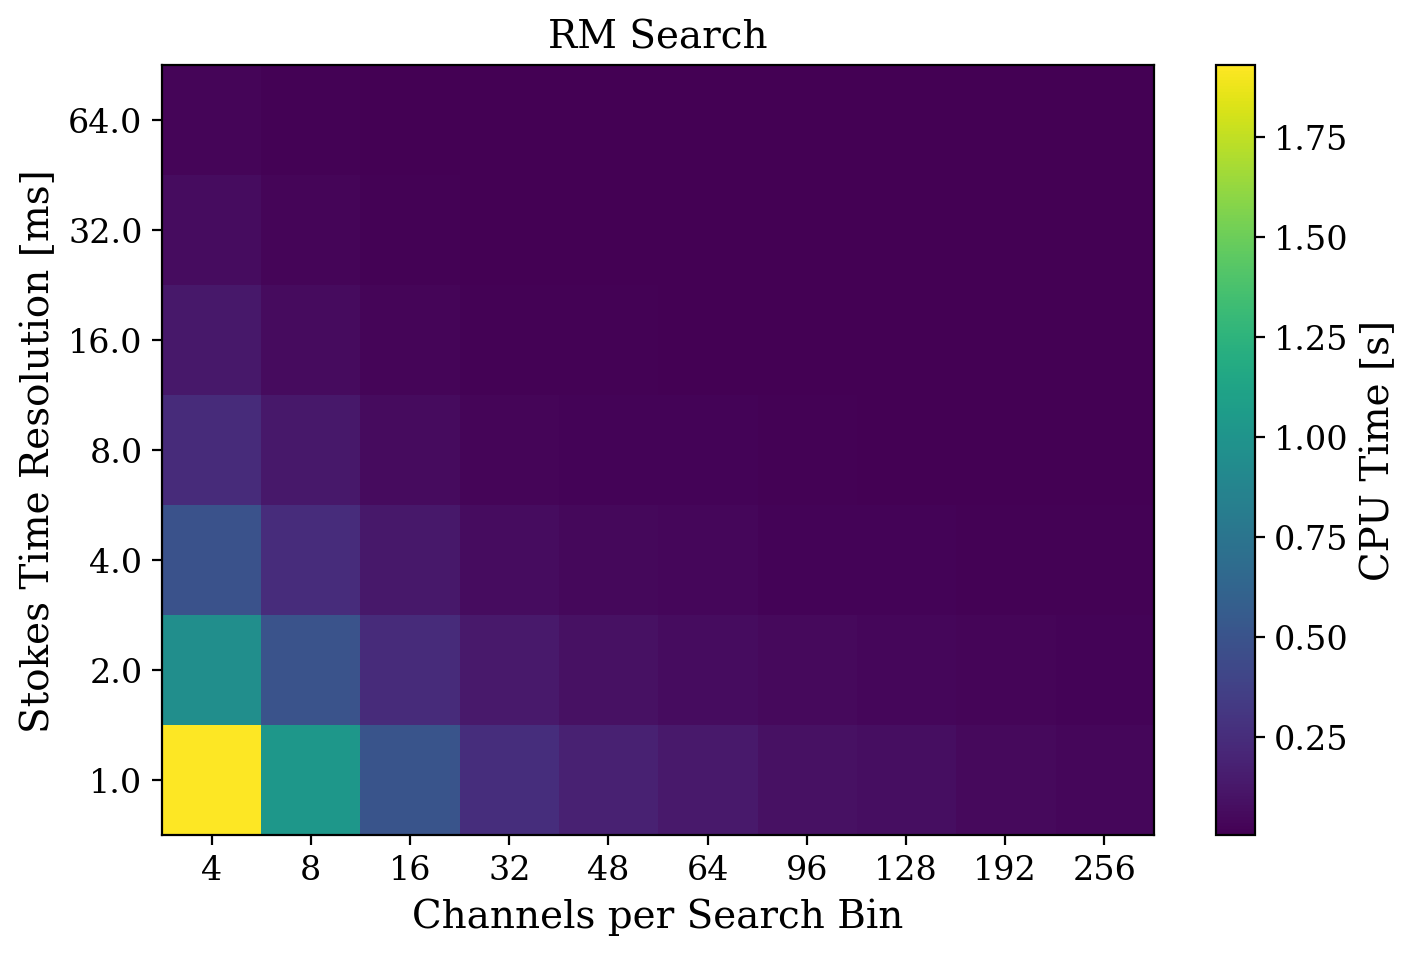

In [ ]:
fig = plt.figure(figsize=(8, 5), dpi=200)

# Data
extent = [-0.5, len(param_vals)-0.5, -0.5, len(stokes_time_res)-0.5]
im = plt.imshow(CPU_time_search,  # given as shape (y,x) = (Ntime_res, Nparam)
                aspect='auto',
                origin='lower',  # put origin in lower left corner
                cmap='viridis',
                # norm=LogNorm()
               )
plt.colorbar(label='CPU Time [s]')

# Centered ticks
xticks = np.arange(len(param_vals))
yticks = np.arange(len(stokes_time_res))
plt.xticks(xticks, param_vals)
plt.yticks(yticks, [np.round(t.value, 1) for t in stokes_time_res])

# Labels
plt.xlabel(param_label)
plt.ylabel('Raw Time Resolution [ms]')
plt.title('RM Search')

# plt.savefig()
plt.show()

RM peak SNR

In [ ]:
# make same plot but with snr of detected peak